# Setup

In [22]:
import pandas as pd
import torch
from src.template_generation import *
from src.uid import *
from src.unigram import UnigramLM
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import permutations
import nltk
nltk.download("names")
from nltk.corpus import names

[nltk_data] Downloading package names to /Users/tzhang04/nltk_data...
[nltk_data]   Package names is already up-to-date!


In [23]:
# Load model
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")  # metal for mac
else:
    device = torch.device("cpu")
print("Loading model...", end="")
tokenizer, model, _ = load_lm(model_name='distilgpt2', device=device)

Loading model...

Loading weights: 100%|██████████| 76/76 [00:00<00:00, 1458.53it/s, Materializing param=transformer.wte.weight]            
GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# Experiments

In [ ]:
active_templates = [
    
]
templates = pd.DataFrame({
    "sent_id": range(len(passive_templates)),
    "passive_template": passive_templates,
    "active_template": active_templates
})

In [27]:
templates.head()

,sent_id,passive_template,active_template
0,0,"During the intermission, <PRE> was standing wi...","During the intermission, <PRE> was standing wi..."
1,1,"On a crisp autumn morning, <PRE> was jogging t...","On a crisp autumn morning, <PRE> was jogging t..."
2,2,"At the end of a long semester, <PRE> was celeb...","At the end of a long semester, <PRE> was celeb..."
3,3,<PRE> was rehearsing with <CTL> in the small s...,<PRE> was rehearsing with <CTL> in the small s...
4,4,"During the charity gala last spring, <PRE> was...","During the charity gala last spring, <PRE> was..."


## Generate data

In [10]:
tokenizer("Abagail")

{'input_ids': [4826, 363, 603], 'attention_mask': [1, 1, 1]}

In [50]:
variants = []
names_list = names.words("female.txt") + names.words("male.txt")
np.random.seed(3)
names_sample = np.random.choice(names_list, size=4)
print(names_sample)
for idx, row in templates.iterrows():
    for perm in permutations(names_sample):
        for template in [row['passive_template'], row['active_template']]:
            result = generate_variants(template, *perm, template==row['passive_template'])
            result['sent_id'] = row['sent_id']
            variants.append(result)
    
variants = pd.concat(variants, ignore_index=True)
for sent in np.random.choice(variants['sentence'], 10):
    print(sent)

['Gilles' 'Eugine' 'Marie' 'Estell']
Eugine was volunteering with Gilles at the local food bank on a cold December morning. Estell was warmly thanked by Marie for their tireless dedication to the community over the past year.
On the last day of the conference, Eugine was networking with Gilles in the grand atrium of the convention center. Eugine pulled Estell aside and pitched a groundbreaking new business idea.
During the film festival, Eugine was attending screenings with Marie at the grand old theater on the main boulevard. Eugine enthusiastically recommended a film to Gilles during the evening break.
Gilles was traveling with Eugine through the winding streets of the old quarter on a warm evening. Gilles was excitedly flagged down by Estell after being spotted outside a small bookshop.
On a busy afternoon at the sports complex, Gilles was training with Marie on the far side of the field. Gilles was firmly encouraged by Eugine to push through the last grueling set of drills.
Eugine 

In [51]:
variants.head()

,patient,agent,control,passive,subject,object,given,sentence,sent_id
0,Eugine,Gilles,"(Marie, Estell)",True,Eugine,Gilles,Gilles,"During the intermission, Gilles was standing w...",0
1,Eugine,Gilles,"(Marie, Estell)",True,Eugine,Gilles,Eugine,"During the intermission, Eugine was standing w...",0
2,Eugine,Gilles,"(Marie, Estell)",True,Eugine,Gilles,Marie,"During the intermission, Marie was standing wi...",0
3,Eugine,Gilles,"(Marie, Estell)",False,Gilles,Eugine,Gilles,"During the intermission, Gilles was standing w...",0
4,Eugine,Gilles,"(Marie, Estell)",False,Gilles,Eugine,Eugine,"During the intermission, Eugine was standing w...",0


In [54]:
uid_results = []
unigram = UnigramLM(tokenizer)
unigram.fit(" ".join(variants['sentence']), uid_unit="word")
for variant in tqdm(variants['sentence']):
    context, sentence = variant.split(". ")
    context += "."
    tokens, surprisals = compute_surprisal(sentence, 
                    context, 
                    sentences=[context, sentence], 
                    sent_idx=1, 
                    tokenizer=tokenizer, 
                    model=model,
                    device=device)
    surprisals, units = process_surprisals(tokenizer,
                                        tokens,
                                        surprisals,
                                        uid_unit="word")
    uni_probs, _ = unigram(tokens)
    result = get_uid_metrics(surprisals, uni_probs)
    result['units'] = units
    uid_results.append(result)
uid_results = pd.DataFrame(uid_results)
uid_results.head(3)

100%|██████████| 4320/4320 [18:01<00:00,  3.99it/s]


,raw_surps,surp_mean,surp_slor,uid_std,uid_mad,uid_pwd,uid_range,uid_cv,uid_slope,uid_len,units
0,"[42.929097175598145, 3.449418544769287, 13.995...",7.753062,-0.470657,10.825207,6.866065,167.033809,41.969730,1.396249,-1.366619,13,"[Eugine, Ġwas, Ġtapped, Ġon, Ġthe, Ġshoulder, ..."
1,"[20.523894518613815, 2.4477720260620117, 14.35...",6.599853,0.682552,6.246921,5.382074,95.152020,19.453560,0.946524,-0.564903,13,"[Eugine, Ġwas, Ġtapped, Ġon, Ġthe, Ġshoulder, ..."
2,"[41.69917440414429, 3.0964548587799072, 14.370...",8.221092,-0.938687,10.696373,7.454958,186.559965,40.623636,1.301089,-1.305117,13,"[Eugine, Ġwas, Ġtapped, Ġon, Ġthe, Ġshoulder, ..."


In [60]:
variants_full = pd.concat([variants, uid_results], axis=1)
variants_full.head(3)

,patient,agent,control,passive,subject,object,given,sentence,sent_id,given_first,...,surp_mean,surp_slor,uid_std,uid_mad,uid_pwd,uid_range,uid_cv,uid_slope,uid_len,units
0,Eugine,Gilles,"(Marie, Estell)",True,Eugine,Gilles,Gilles,"During the intermission, Gilles was standing w...",0,False,...,7.753062,-0.470657,10.825207,6.866065,167.033809,41.969730,1.396249,-1.366619,13,"[Eugine, Ġwas, Ġtapped, Ġon, Ġthe, Ġshoulder, ..."
1,Eugine,Gilles,"(Marie, Estell)",True,Eugine,Gilles,Eugine,"During the intermission, Eugine was standing w...",0,True,...,6.599853,0.682552,6.246921,5.382074,95.152020,19.453560,0.946524,-0.564903,13,"[Eugine, Ġwas, Ġtapped, Ġon, Ġthe, Ġshoulder, ..."
2,Eugine,Gilles,"(Marie, Estell)",True,Eugine,Gilles,Marie,"During the intermission, Marie was standing wi...",0,False,...,8.221092,-0.938687,10.696373,7.454958,186.559965,40.623636,1.301089,-1.305117,13,"[Eugine, Ġwas, Ġtapped, Ġon, Ġthe, Ġshoulder, ..."


In [61]:
variants_full["given_first"] = variants_full["given"] == variants_full["subject"]
variants_full["given_last"] = variants_full["given"] == variants_full["object"]
variants_full["given_pos"] = ["f" if variants_full["given_first"].iloc[i] else "l" if variants_full['given_last'].iloc[i] else "c"
                              for i in range(variants_full.shape[0])]
variants_full.head(3)

,patient,agent,control,passive,subject,object,given,sentence,sent_id,given_first,...,surp_mean,surp_slor,uid_std,uid_mad,uid_pwd,uid_range,uid_cv,uid_slope,uid_len,units
0,Eugine,Gilles,"(Marie, Estell)",True,Eugine,Gilles,Gilles,"During the intermission, Gilles was standing w...",0,False,...,7.753062,-0.470657,10.825207,6.866065,167.033809,41.969730,1.396249,-1.366619,13,"[Eugine, Ġwas, Ġtapped, Ġon, Ġthe, Ġshoulder, ..."
1,Eugine,Gilles,"(Marie, Estell)",True,Eugine,Gilles,Eugine,"During the intermission, Eugine was standing w...",0,True,...,6.599853,0.682552,6.246921,5.382074,95.152020,19.453560,0.946524,-0.564903,13,"[Eugine, Ġwas, Ġtapped, Ġon, Ġthe, Ġshoulder, ..."
2,Eugine,Gilles,"(Marie, Estell)",True,Eugine,Gilles,Marie,"During the intermission, Marie was standing wi...",0,False,...,8.221092,-0.938687,10.696373,7.454958,186.559965,40.623636,1.301089,-1.305117,13,"[Eugine, Ġwas, Ġtapped, Ġon, Ġthe, Ġshoulder, ..."


In [62]:
variants_full.groupby(['passive', 'given_pos'])[["surp_slor", "uid_std", "uid_pwd"]].mean()

surp_slor   uid_std     uid_pwd
passive given_pos                                 
False   c          -2.410442  8.522986   75.165584
        f          -1.255146  6.085303   55.196329
        l          -1.434977  8.189939   56.984004
True    c          -2.008431  8.177257  124.949247
        f          -0.993296  6.192918   91.513529
        l          -1.180644  7.696324  100.726143

<Axes: xlabel='passive', ylabel='uid_std'>

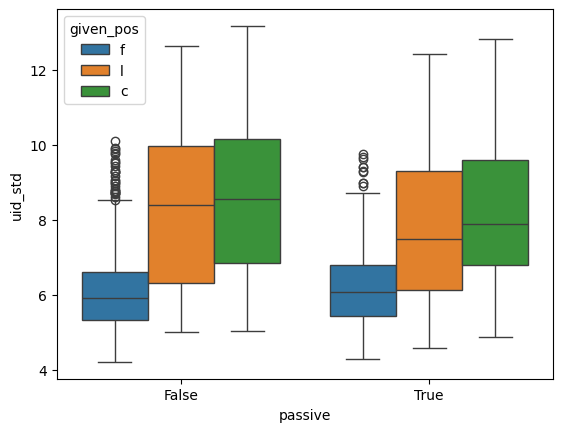

In [63]:
sns.boxplot(data=variants_full, x='passive', y='uid_std', hue='given_pos')

In [64]:
variants_full[(variants_full['given']=='Buddy') & (variants_full['subject']=='Chico')]

,patient,agent,control,passive,subject,object,given,sentence,sent_id,given_first,...,surp_mean,surp_slor,uid_std,uid_mad,uid_pwd,uid_range,uid_cv,uid_slope,uid_len,units


([<matplotlib.axis.XTick at 0x330bd82d0>,
 [Text(0, 0, 'Eugine:Marie'),
  Text(1, 0, 'was'),
  Text(2, 0, 'tapped'),
  Text(3, 0, 'on'),
  Text(4, 0, 'the'),
  Text(5, 0, 'shoulder'),
  Text(6, 0, 'by'),
  Text(7, 0, 'Gilles,'),
  Text(8, 0, 'who'),
  Text(9, 0, 'struck'),
  Text(10, 0, 'up'),
  Text(11, 0, 'a'),
  Text(12, 0, 'conversation.')])

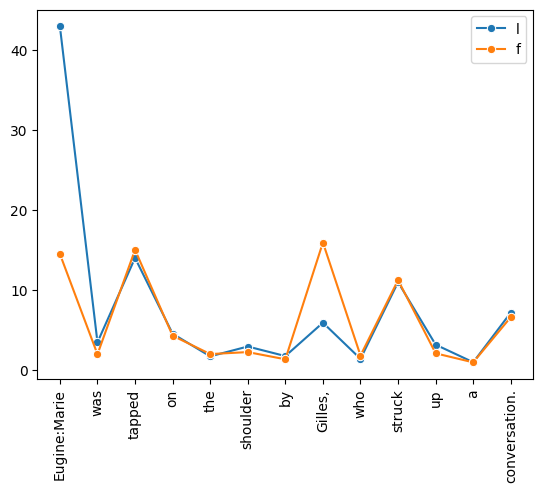

In [65]:
sentence = variants_full.iloc[0]
surprisals = sentence['raw_surps']
units1 = [s.strip('Ġ') for s in sentence['units']]
sns.lineplot(x=range(len(surprisals)), y=surprisals, marker='o', label=sentence['given_pos'])

sentence = variants_full.iloc[19]
surprisals = sentence['raw_surps']
units2 = [s.strip('Ġ') for s in sentence['units']]
sns.lineplot(x=range(len(surprisals)), y=surprisals, marker='o', label=sentence['given_pos'])

plt.xticks(ticks=range(len(surprisals)), 
           labels=[f"{unit1}:{unit2}" if unit1 != unit2 else unit1 for unit1, unit2 in zip(units1, units2)], 
           rotation=90)